# LR3 — Decision Tree Classification

Dataset: adult.csv (Census Income)

Target: income (<=50K / >50K)

1. Import
2. Load data
3. EDA
4. Preprocessing
5. Train decision tree
6. Evaluate
7. Improve

In [1]:
# 1 - Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
%matplotlib inline

In [2]:
# 2 - Load data
df = pd.read_csv("adult.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
# 3 - EDA
print("Missing values:")
print(df.isnull().sum())
print(f"\nTarget distribution:")
print(df['income'].value_counts())
print(f"\nNumeric stats:")
df.describe()

Missing values:
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

Target distribution:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Numeric stats:


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


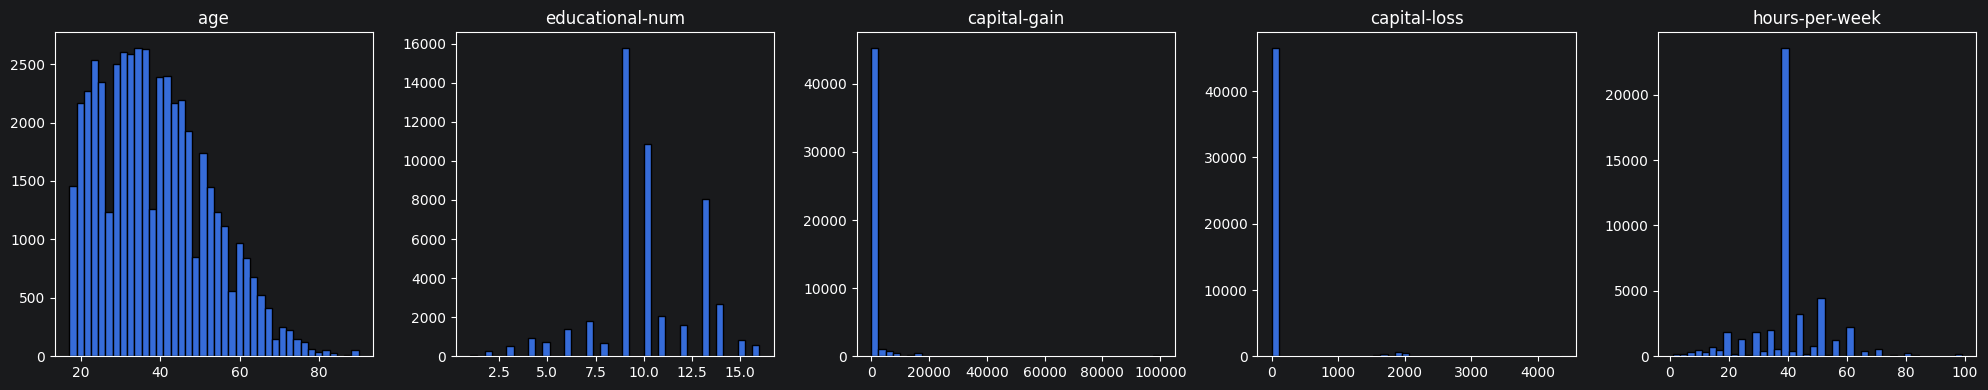

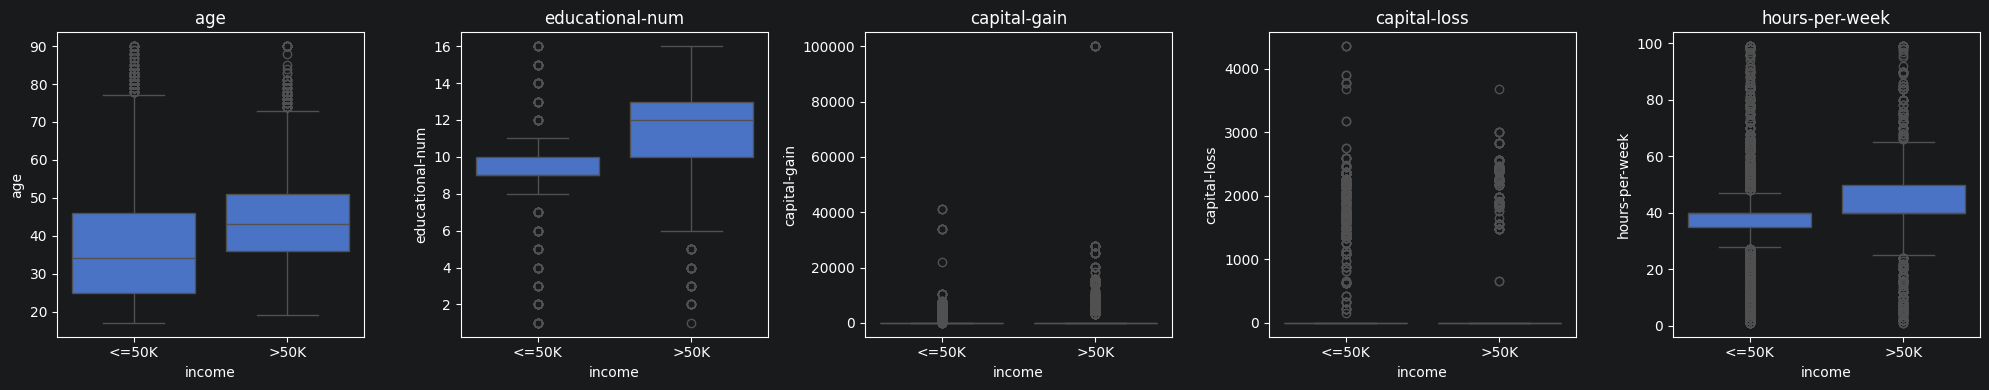

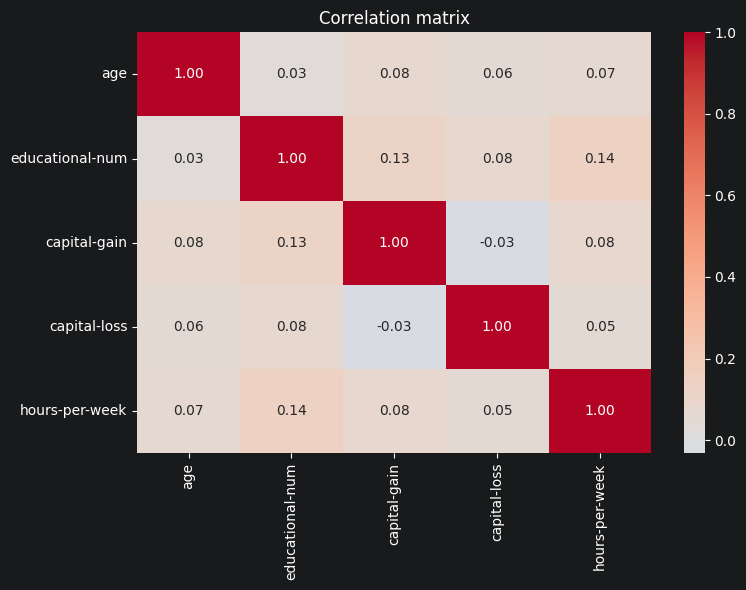

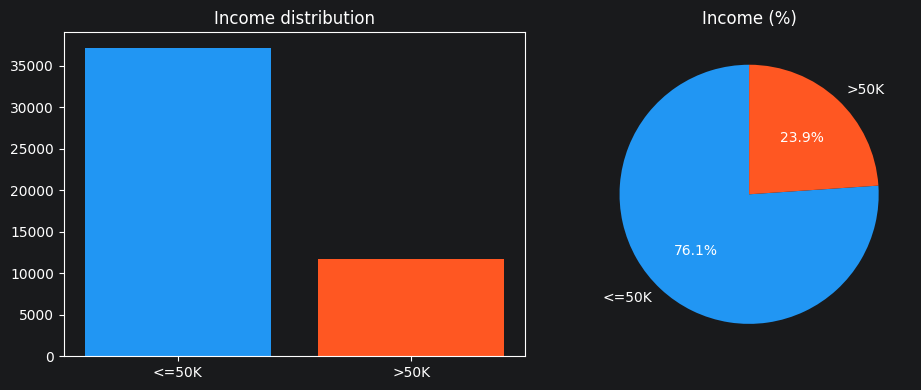

In [4]:
# 3 (cont) - Visualizations

num_cols = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Numeric distributions
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, edgecolor='black')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Boxplots by income
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='income', y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# Correlation
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

# Target balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
income_counts = df['income'].value_counts()
axes[0].bar(income_counts.index, income_counts.values, color=['#2196F3', '#FF5722'])
axes[0].set_title('Income distribution')
axes[1].pie(income_counts.values, labels=income_counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF5722'], startangle=90)
axes[1].set_title('Income (%)')
plt.tight_layout()
plt.show()

In [5]:
# 4 - Preprocessing

# Drop fnlwgt (census weight, not predictive)
df = df.drop(columns=['fnlwgt'])

# Encode target
df['income'] = (df['income'] == '>50K').astype(int)

# Encode categorical features
cat_features = df.select_dtypes(include=['object', 'str']).columns.tolist()
label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Feature matrix
feature_cols = [c for c in df.columns if c != 'income']
X = df[feature_cols]
y = df['income']

print(f"Features: {X.shape}")
print(f"Target: {y.value_counts().to_dict()}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Features: (48842, 13)
Target: {0: 37155, 1: 11687}

Train: (39073, 13), Test: (9769, 13)


In [6]:
# 5 - Train Decision Tree (baseline)

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)
print(f"Baseline Accuracy: {acc_base:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=['<=50K', '>50K']))

print(f"Tree depth: {dt_base.get_depth()}")
print(f"Number of leaves: {dt_base.get_n_leaves()}")

Baseline Accuracy: 0.8236

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.89      0.89      7431
        >50K       0.64      0.60      0.62      2338

    accuracy                           0.82      9769
   macro avg       0.76      0.75      0.75      9769
weighted avg       0.82      0.82      0.82      9769

Tree depth: 43
Number of leaves: 7027


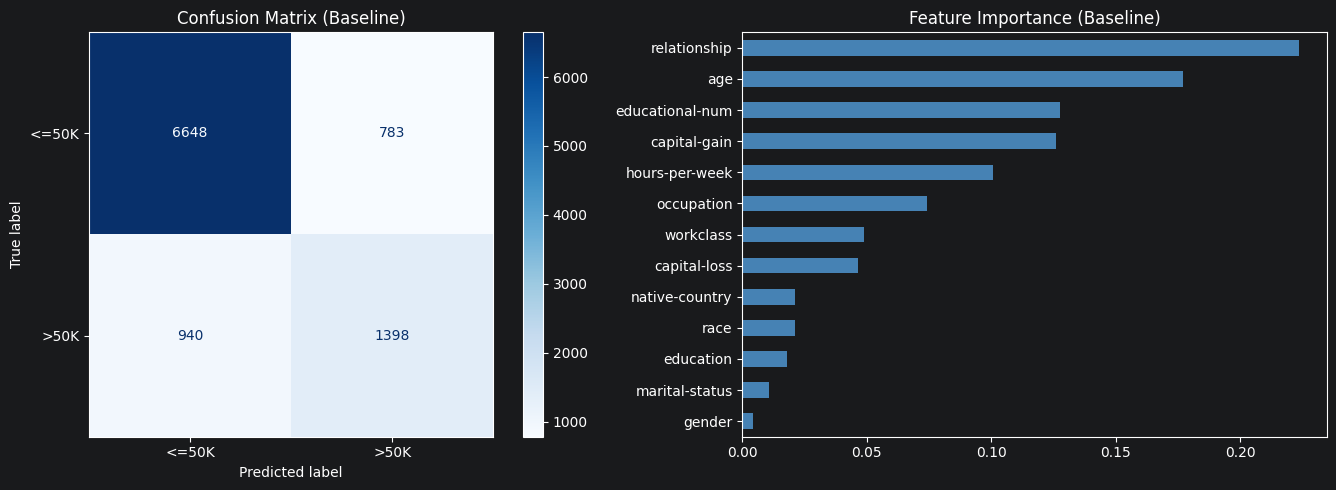

Cross-validation accuracy: 0.8213 (+/- 0.0051)


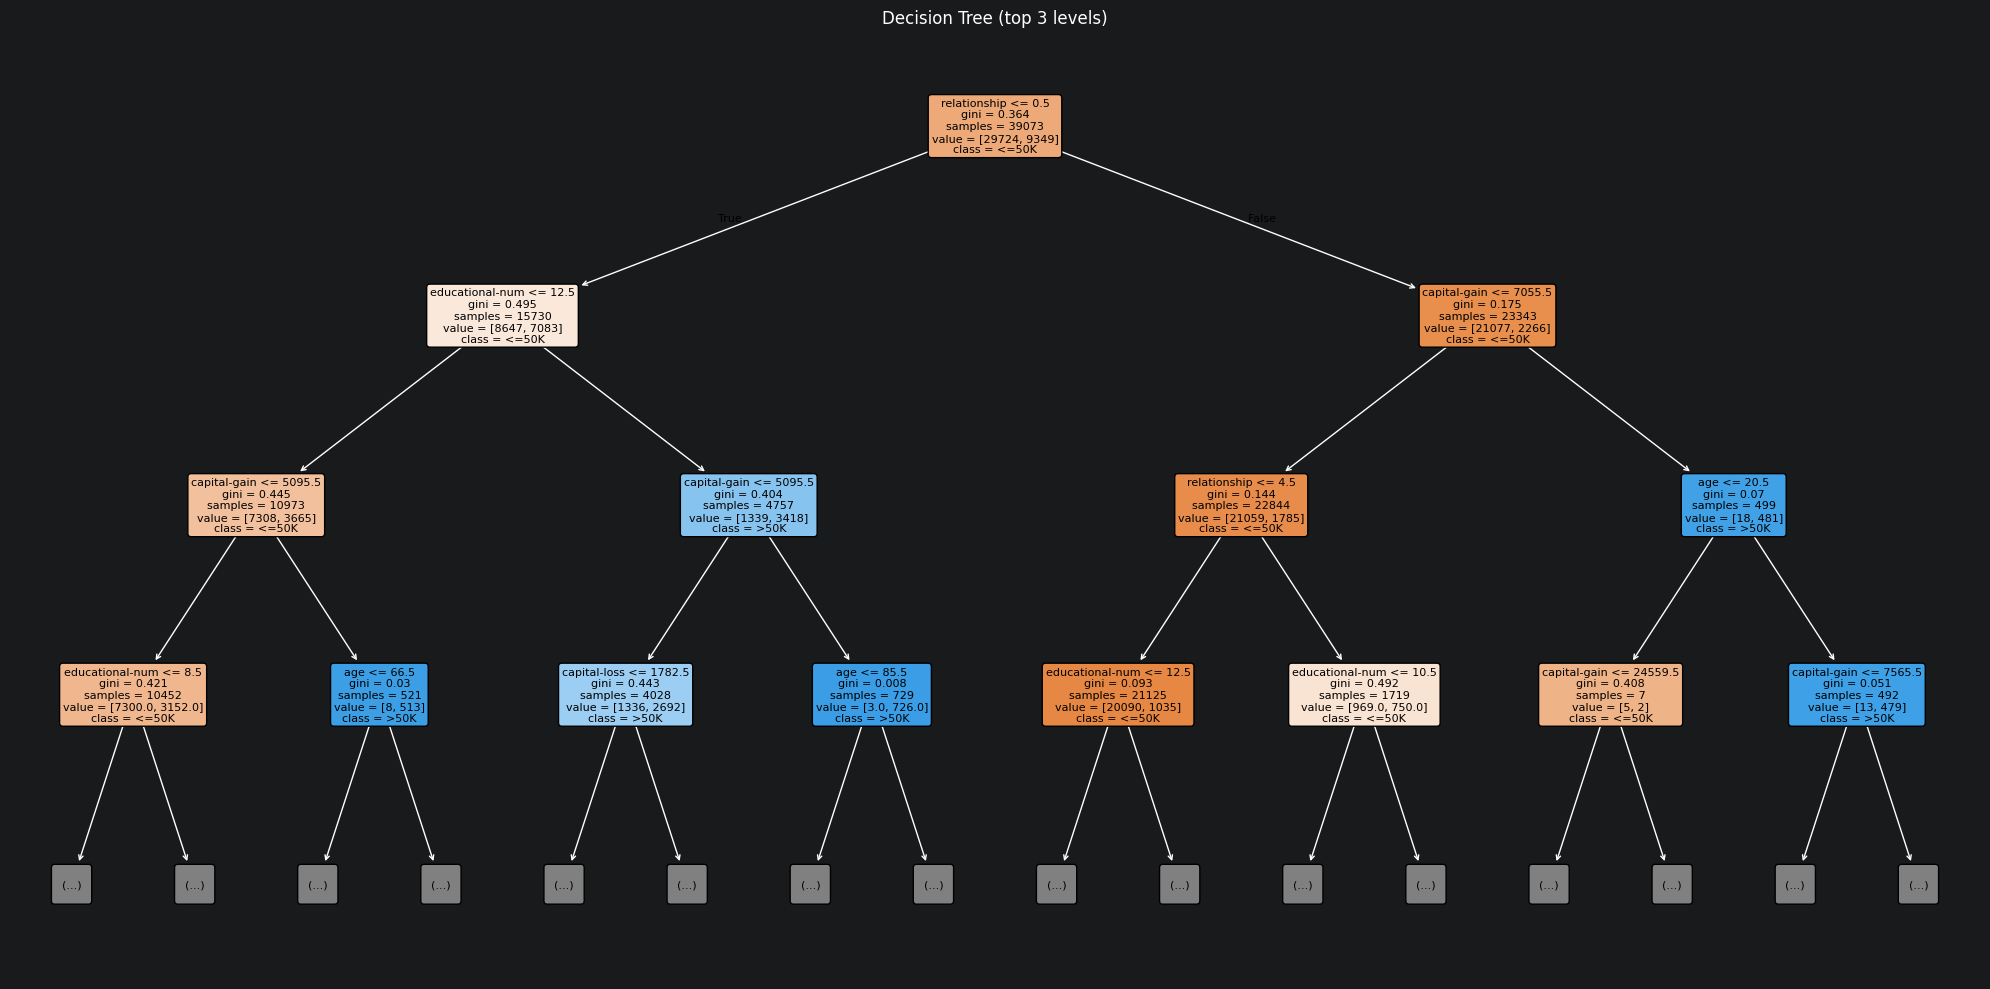

In [7]:
# 6 - Evaluate Decision Tree

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(dt_base, X_test, y_test, ax=axes[0],
                                      display_labels=['<=50K', '>50K'], cmap='Blues')
axes[0].set_title('Confusion Matrix (Baseline)')

importances = pd.Series(dt_base.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance (Baseline)')
plt.tight_layout()
plt.show()

cv_scores = cross_val_score(dt_base, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_base, max_depth=3, feature_names=feature_cols,
          class_names=['<=50K', '>50K'],
          filled=True, rounded=True, fontsize=8, ax=ax)
for text in ax.texts:
    text.set_color('black')
plt.title('Decision Tree (top 3 levels)')
plt.tight_layout()
plt.show()

In [8]:
# 7 - Improve Decision Tree (GridSearchCV)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

dt_best = grid_search.best_estimator_
y_pred_best = dt_best.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print(f"\nImproved test accuracy: {acc_best:.4f}")
print(f"Baseline test accuracy: {acc_base:.4f}")
print(f"Improvement: {acc_best - acc_base:+.4f}")
print(f"\nClassification Report (improved):")
print(classification_report(y_test, y_pred_best, target_names=['<=50K', '>50K']))

Best params: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV accuracy: 0.8545

Improved test accuracy: 0.8642
Baseline test accuracy: 0.8236
Improvement: +0.0405

Classification Report (improved):
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7431
        >50K       0.77      0.61      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



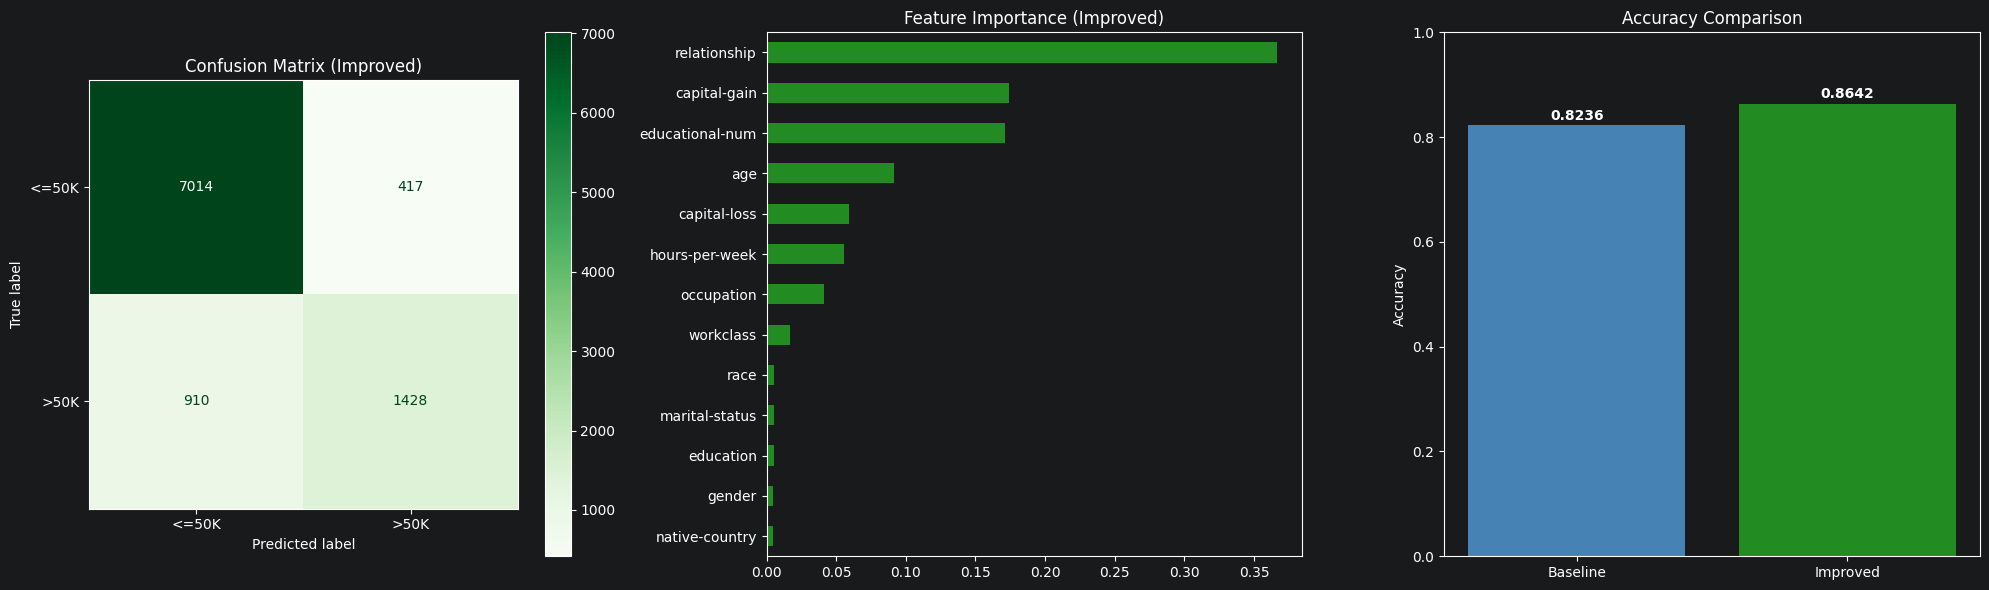

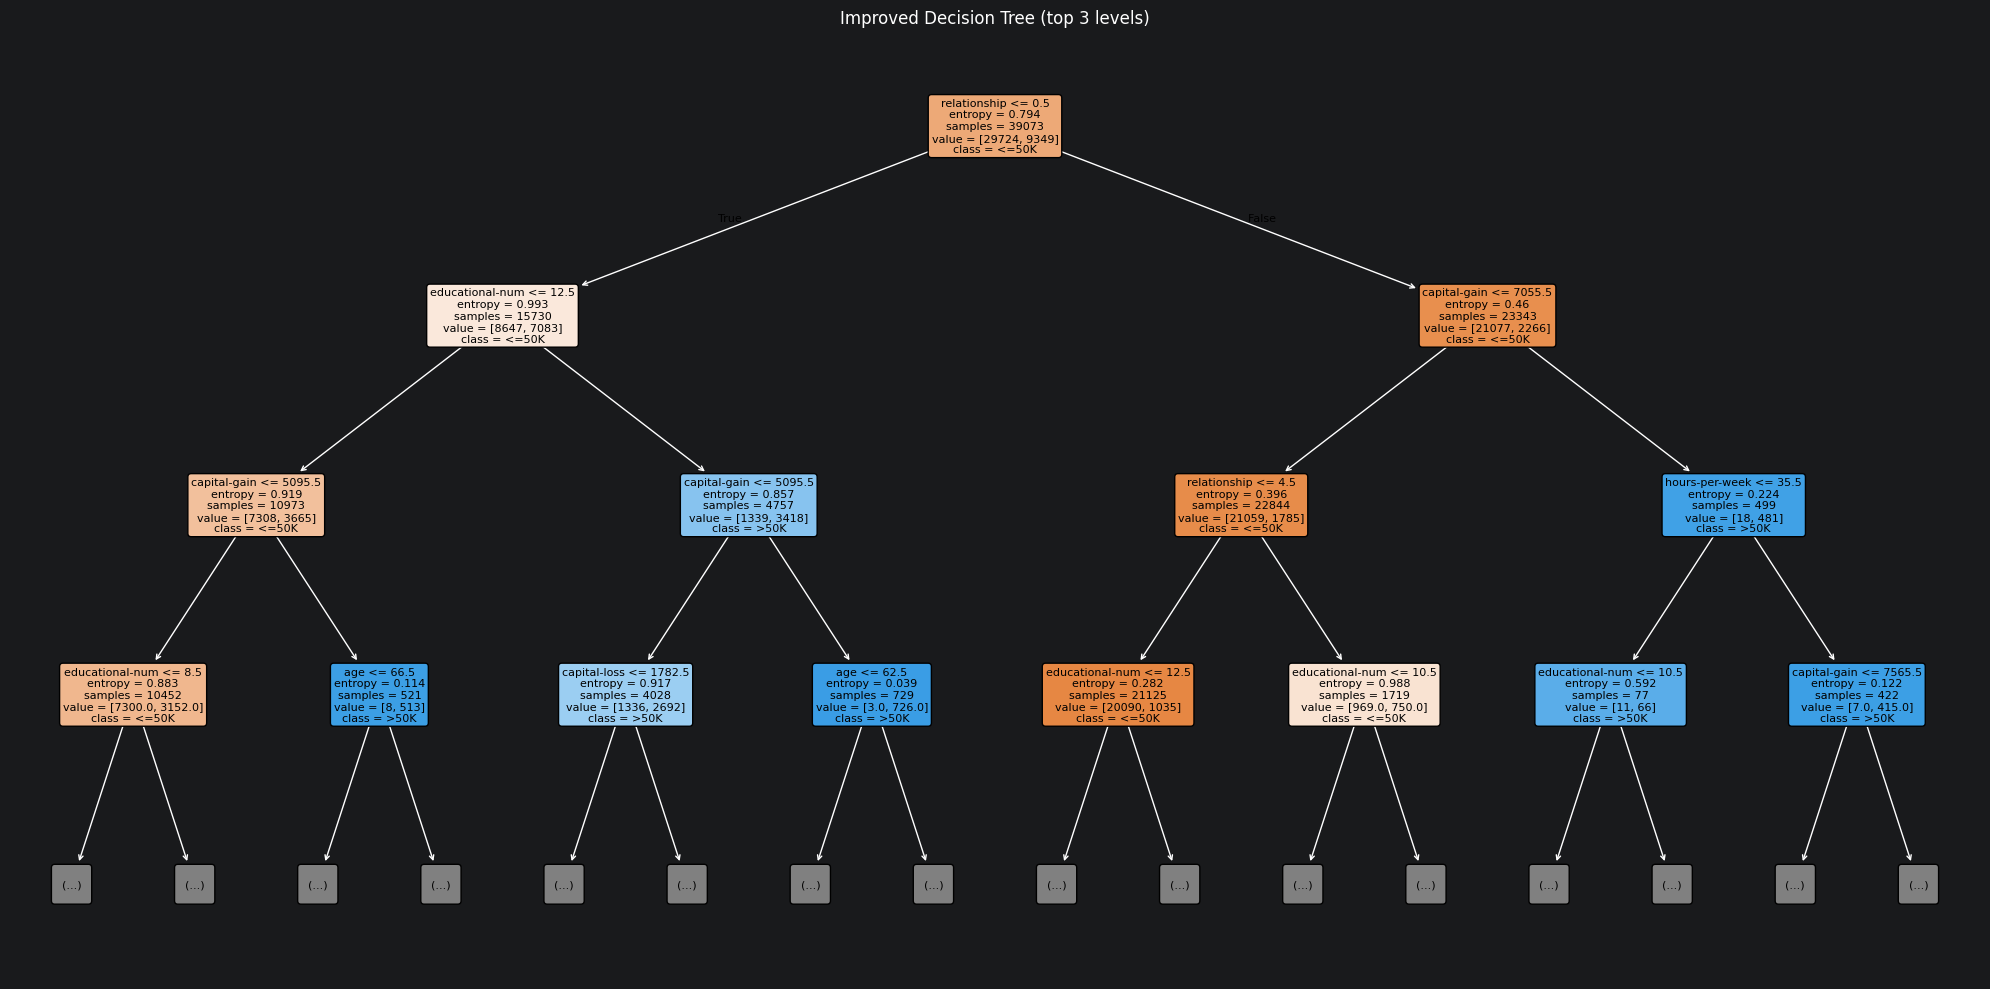

In [9]:
# 7 (cont) - Compare baseline vs improved

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ConfusionMatrixDisplay.from_estimator(dt_best, X_test, y_test, ax=axes[0],
                                      display_labels=['<=50K', '>50K'], cmap='Greens')
axes[0].set_title('Confusion Matrix (Improved)')

importances_best = pd.Series(dt_best.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances_best.plot.barh(ax=axes[1], color='forestgreen')
axes[1].set_title('Feature Importance (Improved)')

models = ['Baseline', 'Improved']
accs = [acc_base, acc_best]
bars = axes[2].bar(models, accs, color=['steelblue', 'forestgreen'])
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Accuracy Comparison')
for bar, acc in zip(bars, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_best, max_depth=3, feature_names=feature_cols,
          class_names=['<=50K', '>50K'],
          filled=True, rounded=True, fontsize=8, ax=ax)
for text in ax.texts:
    text.set_color('black')
plt.title('Improved Decision Tree (top 3 levels)')
plt.tight_layout()
plt.show()